## Imports

In [1]:
import time
import math
import random
import copy
from collections import defaultdict, Counter
import re
import openpyxl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange
from IPython.display import display

In [2]:
random.seed(42)
np.random.seed(42)

## Load Data

In [3]:
courses_raw = pd.read_csv("D:\Berkas UB\SKRIPSI\COATI\Coati_Optimization_University-Course-Schedulling\data\Ganjil\data_mk_DSI_semester_ganjil.csv")
rooms_df = pd.read_csv("D:\Berkas UB\SKRIPSI\COATI\Coati_Optimization_University-Course-Schedulling\data\Ruang Kuliah.csv")
labs_df = pd.read_excel("D:\Berkas UB\SKRIPSI\COATI\Coati_Optimization_University-Course-Schedulling\data\Laboratorium.xlsx")

courses_raw.columns = [c.strip() for c in courses_raw.columns]
rooms_df.columns = [c.strip() for c in rooms_df.columns]
labs_df.columns = [c.strip() for c in labs_df.columns]

In [4]:
def to_int_safe(x, default=0):
    if pd.isna(x):
        return default          
    try:
        return int(float(x))
    except:
        return default


In [5]:
SECTION_LABELS = ['A', 'B', 'C', 'D']
MAX_SECTIONS_WAJIB = 4
MAX_SECTIONS_MINAT_INITIAL = 4
MIN_SECTIONS_MINAT = 1
 
# ── Step 1: Konsolidasi courses_raw -> canonical course per (kode, prodi) ──
canonical_courses = {}
 
for idx, row in courses_raw.iterrows():
    kode  = str(row.iloc[0]).strip()
    prodi = str(row.iloc[2]).strip()
    key = (kode, prodi)
 
    if key not in canonical_courses:
        canonical_courses[key] = {
            'kode'      : kode,
            'prodi'     : prodi,
            'nama'      : str(row.iloc[1]).strip(),
            'prioritas' : to_int_safe(row.iloc[3]),
            'dosen_asli': to_int_safe(row.iloc[5], default=0),
            'sks'       : to_int_safe(row.iloc[7]),
            'praktikum' : to_int_safe(row.iloc[8]),
            'kewajiban' : to_int_safe(row.iloc[9]),
        }
 
print(f"Total grup (kode, prodi) unik: {len(canonical_courses)}")

Total grup (kode, prodi) unik: 117


In [6]:
# ── Step 2: Generate KELAS (section A/B/C/D) per grup ───────────────────────
courses = {}
section_groups = defaultdict(list)
 
for (kode, prodi), info in canonical_courses.items():
    is_wajib = info['kewajiban'] == 1
    n_sections = MAX_SECTIONS_WAJIB if is_wajib else MAX_SECTIONS_MINAT_INITIAL
 
    for sec_idx in range(n_sections):
        label = SECTION_LABELS[sec_idx]
        section_key = f"{kode}__{prodi}__{label}"
 
        courses[section_key] = {
            'kode'         : kode,
            'prodi'        : prodi,
            'nama'         : info['nama'],
            'prioritas'    : info['prioritas'],
            'dosen_asli'   : info['dosen_asli'],
            'dosen'        : None,
            'sks'          : info['sks'],
            'praktikum'    : info['praktikum'],
            'kewajiban'    : info['kewajiban'],
            'section'      : label,
            'is_wajib'     : is_wajib,
            'kode_prodi'   : (kode, prodi),
            'active'       : True,
            'is_substitusi': False,
        }
        section_groups[(kode, prodi)].append(section_key)
 
course_keys = list(courses.keys())
print(f"Total kelas (course_keys) ter-generate: {len(course_keys)}")

Total kelas (course_keys) ter-generate: 468


In [7]:
def assign_dosen_to_sections(courses, course_keys):
    substitution_log = []
 
    all_known_dosen = set()
    for k in course_keys:
        d = courses[k]['dosen_asli']
        if d and d != 0:
            all_known_dosen.add(d)
 
    def lecture_count_of(k):
        c = courses[k]
        return max(0, c['sks'] - 2) if c['praktikum'] == 1 else c['sks']
 
    dosen_sks = defaultdict(int)
    needs_substitution = []
 
    for k in course_keys:
        c = courses[k]
        if c['dosen_asli'] and c['dosen_asli'] != 0:
            c['dosen'] = c['dosen_asli']
            c['is_substitusi'] = False
            dosen_sks[c['dosen']] += lecture_count_of(k)
        else:
            needs_substitution.append(k)
 
    for k in needs_substitution:
        c = courses[k]
        if not all_known_dosen:
            c['dosen'] = None
            c['is_substitusi'] = False
            substitution_log.append({
                'section': k, 'kode': c['kode'], 'prodi': c['prodi'], 'kelas': c['section'],
                'dosen_asli': c['dosen_asli'], 'dosen_pengganti': None,
                'alasan': 'Tidak ada dosen terdaftar di seluruh data utk disubstitusi'
            })
            continue
 
        substitute = min(all_known_dosen, key=lambda d: dosen_sks[d])
        sks_sebelum = dosen_sks[substitute]
        c['dosen'] = substitute
        c['is_substitusi'] = True
        dosen_sks[substitute] += lecture_count_of(k)
 
        substitution_log.append({
            'section': k, 'kode': c['kode'], 'prodi': c['prodi'], 'kelas': c['section'],
            'dosen_asli': c['dosen_asli'], 'dosen_pengganti': substitute,
            'alasan': (f"MK {c['kode']} ({c['prodi']}) kelas {c['section']} tidak punya "
                       f"dosen terdaftar; diisi dosen {substitute} "
                       f"(SKS dosen tsb saat itu: {sks_sebelum})")
        })
 
    under_loaded = {d: s for d, s in dosen_sks.items() if s < 12}
    return substitution_log, dict(dosen_sks), under_loaded
 
 
substitution_log, dosen_sks_estimasi, dosen_kurang_sks = assign_dosen_to_sections(courses, course_keys)
print(f"Total substitusi dosen: {len(substitution_log)}")
if dosen_kurang_sks:
    print(f"⚠ Dosen yg masih kurang SKS (estimasi awal): {dosen_kurang_sks}")

Total substitusi dosen: 0
⚠ Dosen yg masih kurang SKS (estimasi awal): {90: 8, 46: 4, 62: 8, 11: 4}


In [8]:
def parse_classroom(kode):
    m = re.match(r'([A-Z])(\d+)\.', kode)
    return {
        'kode_ruang': kode,
        'Gedung': m.group(1),
        'Lantai': int(m.group(2))
    }

class_rooms = [parse_classroom(k) for k in rooms_df.iloc[:,0].astype(str)]
class_rooms[:3]

[{'kode_ruang': 'F11.1', 'Gedung': 'F', 'Lantai': 11},
 {'kode_ruang': 'F11.3', 'Gedung': 'F', 'Lantai': 11},
 {'kode_ruang': 'F11.4', 'Gedung': 'F', 'Lantai': 11}]

In [9]:
lab_rooms = []

for _, row in labs_df.iterrows():
    kode = str(row['Kode Ruang']).strip()
    m = re.match(r'([A-Z])(\d+)\.', kode)
    lab_rooms.append({
        'kode_ruang': kode,
        'Gedung'    : m.group(1) if m else 'G',
        'Lantai'    : int(m.group(2)) if m else 1
    })

lab_room_codes = {r['kode_ruang'] for r in lab_rooms}

lab_rooms[:3]

[{'kode_ruang': 'G1.2', 'Gedung': 'G', 'Lantai': 1},
 {'kode_ruang': 'G1.3', 'Gedung': 'G', 'Lantai': 1},
 {'kode_ruang': 'G1.4', 'Gedung': 'G', 'Lantai': 1}]

In [10]:
room_info = {}
for r in class_rooms:
    room_info[r['kode_ruang']] = {'Gedung': r['Gedung'], 'Lantai': r['Lantai']}
for r in lab_rooms:
    room_info[r['kode_ruang']] = {'Gedung': r['Gedung'], 'Lantai': r['Lantai']}
 
print(f"Total ruangan terdaftar: {len(room_info)}")

Total ruangan terdaftar: 47


## Timeslot generation

In [11]:
DAYS = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']
 
# Batas jam operasional (dalam menit sejak 00:00)
LECTURE_START_MIN  = 7 * 60        # 07:00
LECTURE_END_MIN    = 18 * 60       # 18:00  (sesi terakhir harus SELESAI sebelum ini)
PRACT_START_MIN    = 7 * 60        # 07:00
PRACT_END_MIN      = 18 * 60       # 18:00
 
SKS_DURATION       = 50            # 1 SKS = 50 menit
SLOT_INTERVAL      = 5             # interval antar slot = 5 menit    

# Jam istirahat per hari (dalam menit sejak 00:00)
# Format: (mulai_istirahat, selesai_istirahat)
BREAKS_MIN = {
    'Mon': [(11 * 60, 12 * 60)],
    'Tue': [(11 * 60, 12 * 60)],
    'Wed': [(11 * 60, 12 * 60)],
    'Thu': [(11 * 60, 12 * 60)],
    'Fri': [(11 * 60, 13 * 60)],
}

def is_blocked_by_break(start_min, duration_min, breaks):
    """
    Cek apakah sesi [start_min, start_min+duration_min)
    bertabrakan dengan salah satu blok istirahat.
    """
    end_min = start_min + duration_min
    for b_start, b_end in breaks:
        # overlap jika sesi mulai sebelum istirahat selesai
        # DAN sesi selesai setelah istirahat mulai
        if start_min < b_end and end_min > b_start:
            return True
    return False
 
 
def generate_slots(start_bound, end_bound, sks_per_sess=1):
    """
    Hasilkan semua slot waktu mulai yang valid untuk sesi dengan durasi tertentu.
    sks_per_sess: SKS per sesi (biasanya 1, karena tiap sesi = 1 pertemuan)
    duration    : sks_per_sess * SKS_DURATION menit
    """
    duration = sks_per_sess * SKS_DURATION
    slots = []
    for d in DAYS:
        # Iterasi setiap 5 menit dari awal sampai akhir
        t = start_bound
        while t + duration <= end_bound:
            if not is_blocked_by_break(t, duration, BREAKS_MIN[d]):
                h = t // 60
                m = t % 60
                slots.append((d, h, m))
            t += SLOT_INTERVAL
    return slots
 
 
# Slot untuk lecture (1 sesi = 1 SKS = 50 menit)
# Sesi harus mulai dan selesai dalam LECTURE_START_MIN..LECTURE_END_MIN
available_slots_lecture  = generate_slots(LECTURE_START_MIN,  LECTURE_END_MIN)
 
# Slot untuk praktikum (1 sesi = 1 SKS = 50 menit, tapi batas lebih longgar)
available_slots_practicum = generate_slots(PRACT_START_MIN, PRACT_END_MIN)
 
# Gabungan semua slot unik (untuk index umum)
available_slots = list(dict.fromkeys(
    available_slots_lecture + available_slots_practicum
))
 
SLOT_INDEX = {s: i for i, s in enumerate(available_slots)}
 
# Set untuk pengecekan cepat
lecture_slot_set  = set(available_slots_lecture)
practicum_slot_set = set(available_slots_practicum)
 
print(f"Slot lecture  : {len(available_slots_lecture)}")
print(f"Slot praktikum: {len(available_slots_practicum)}")
print(f"Total slot    : {len(available_slots)}")
print(f"Contoh slot   : {available_slots[:5]}")


Slot lecture  : 498
Slot praktikum: 498
Total slot    : 498
Contoh slot   : [('Mon', 7, 0), ('Mon', 7, 5), ('Mon', 7, 10), ('Mon', 7, 15), ('Mon', 7, 20)]


In [12]:
def sessions_overlap(slot_a, slot_b, dur_a=SKS_DURATION, dur_b=SKS_DURATION):
    """
    Cek apakah dua sesi overlap.
    slot: (hari, jam, menit)
    Sesi A: [start_a, start_a + dur_a)
    Sesi B: [start_b, start_b + dur_b)
    """
    day_a, h_a, m_a = slot_a
    day_b, h_b, m_b = slot_b
    if day_a != day_b:
        return False
    start_a = h_a * 60 + m_a
    start_b = h_b * 60 + m_b
    return start_a < start_b + dur_b and start_b < start_a + dur_a

# Prefensi Waktu Mengajar

In [13]:
USE_PREFERENCE = False

DAY_MAP = {
    'Senin': 'Mon',  'Mon': 'Mon',
    'Selasa': 'Tue', 'Tue': 'Tue',
    'Rabu': 'Wed',   'Wed': 'Wed',
    'Kamis': 'Thu',  'Thu': 'Thu',
    'Jumat': 'Fri',  'Fri': 'Fri'
}

pref_df = pd.read_csv("..\data\Preferensi_Mengajar.csv")
pref_df.columns = [c.strip() for c in pref_df.columns]

pref_map = defaultdict(set)

for _, r in pref_df.iterrows():
    dosen = int(r['dosen'])
    hari = DAY_MAP[r['hari']]
    jam  = int(r['jam'])

    pref_map[dosen].add((hari, jam))

## Struktur Session

In [14]:
def make_empty_schedule():
    sched = {}
    for k in course_keys:
        if not courses[k]['active']:
            continue
        sks = courses[k]['sks']
        pr  = courses[k]['praktikum']
        sessions = []
 
        if pr == 1:
            lecture_count = max(0, sks - 1)
            for _ in range(lecture_count):
                sessions.append({'type':'lecture','slot':None,'room':None})
            sessions.append({'type':'practicum','slot':None,'room':None})
        else:
            for _ in range(sks):
                sessions.append({'type':'lecture','slot':None,'room':None})
 
        sched[k] = sessions
    return sched

# Kandidat Ruangan

In [15]:
room_candidates_per_course = {}

for k in course_keys:
    room_candidates_per_course[k] = {
        'lecture': [r['kode_ruang'] for r in class_rooms],
        'practicum': [r['kode_ruang'] for r in lab_rooms]
    }


# RANDOM & REPAIR

In [16]:
def random_schedule():
    sched = make_empty_schedule()
 
    for k, sessions in sched.items():
        for sess in sessions:
            if sess['type'] == 'lecture':
                valid_indices = [SLOT_INDEX[sl] for sl in available_slots_lecture]
            else:
                valid_indices = [SLOT_INDEX[sl] for sl in available_slots_practicum]
 
            sess['slot'] = random.choice(valid_indices)
 
            rlist = room_candidates_per_course[k][sess['type']]
            sess['room'] = random.choice(rlist) if rlist else None
 
    return sched

In [17]:
# def random_schedule():
#     sched = make_empty_schedule()

#     for k, sessions in sched.items():
#         for sess in sessions:
#             # slot valid
#             sess['slot'] = random.randint(0, len(available_slots)-1)

#             # room valid sesuai tipe
#             rlist = room_candidates_per_course[k][sess['type']]
#             if rlist:
#                 sess['room'] = random.choice(rlist)
#             else:
#                 sess['room'] = None

#     return sched

In [18]:
def repair_schedule(schedule):
    """
    Resolusi konflik berbasis OVERLAP WAKTU (pakai sessions_overlap),
    bukan exact slot-index match.
 
    - room_used  : melacak slot_tuple (hari,jam,menit) yang sudah terpakai per ruang
    - dosen_used : melacak slot_tuple yang sudah terpakai per dosen
                   (mencakup SEMUA tipe sesi — lecture & practicum — supaya
                    Hard#5 'praktikum tidak bentrok dgn teori dosen' ikut terjaga)
 
    Setiap sesi dicoba assign slot, lalu dicek overlap dengan SEMUA sesi
    lain yang sudah ditempatkan di ruang/dosen yang sama. Jika overlap,
    coba slot lain (maks 30x). Setelah berhasil/menyerah, slot final
    dicatat ke room_used & dosen_used untuk sesi berikutnya.
    """
    room_used  = defaultdict(list)   # room  → [slot_tuple, ...]
    dosen_used = defaultdict(list)   # dosen → [slot_tuple, ...]  (semua tipe sesi)
 
    for k, sessions in schedule.items():
        mk = courses[k]
        dosen = mk['dosen']
 
        for s in sessions:
            sess_type = s['type']
            if sess_type == 'lecture':
                valid_indices = [SLOT_INDEX[sl] for sl in available_slots_lecture]
            else:
                valid_indices = [SLOT_INDEX[sl] for sl in available_slots_practicum]
 
            # Pastikan slot & room valid sesuai tipe (seperti sebelumnya)
            if s['slot'] is None or s['slot'] not in valid_indices:
                s['slot'] = random.choice(valid_indices)
            if s['room'] is None:
                rlist = room_candidates_per_course[k][sess_type]
                s['room'] = random.choice(rlist)
 
            # ── FIX UTAMA: cek OVERLAP, bukan exact match (max 30x) ──────
            for _ in range(30):
                curr_tuple = available_slots[s['slot']]
 
                room_conflict = any(
                    sessions_overlap(curr_tuple, rs) for rs in room_used[s['room']]
                )
                dosen_conflict = (
                    dosen is not None and
                    any(sessions_overlap(curr_tuple, ds) for ds in dosen_used[dosen])
                )
 
                if not room_conflict and not dosen_conflict:
                    break
                s['slot'] = random.choice(valid_indices)
 
            # Catat slot final (meski masih ada sisa konflik setelah 30x,
            # akan tetap kena penalti saat evaluate_schedule_detailed —
            # ini wajar untuk kasus yang benar-benar tidak ada slot kosong)
            final_tuple = available_slots[s['slot']]
            room_used[s['room']].append(final_tuple)
            if dosen is not None:
                dosen_used[dosen].append(final_tuple)
 
    return schedule

In [19]:
# def repair_schedule(schedule):
#     used = set()   # (slot_idx, room) yang sudah terpakai
 
#     for k, sessions in schedule.items():
#         for s in sessions:
#             # Pilih pool slot sesuai tipe sesi
#             if s['type'] == 'lecture':
#                 valid_indices = [SLOT_INDEX[sl] for sl in available_slots_lecture]
#             else:
#                 valid_indices = [SLOT_INDEX[sl] for sl in available_slots_practicum]
 
#             if s['slot'] is None or s['slot'] not in valid_indices:
#                 s['slot'] = random.choice(valid_indices)
 
#             if s['room'] is None:
#                 rlist = room_candidates_per_course[k][s['type']]
#                 s['room'] = random.choice(rlist)
 
#             # Resolusi konflik slot+room (max 10x)
#             for _ in range(10):
#                 key = (s['slot'], s['room'])
#                 if key not in used:
#                     break
#                 s['slot'] = random.choice(valid_indices)
 
#             key = (s['slot'], s['room'])
#             used.add(key)
 
#     return schedule

In [20]:
# def repair_schedule(schedule):
#     used = set()
#     for k, sessions in schedule.items():
#         for s in sessions:
#             if s['slot'] is None:
#                 s['slot'] = random.randint(0, len(available_slots)-1)
#             if s['room'] is None:
#                 rlist = room_candidates_per_course[k][s['type']]
#                 s['room'] = random.choice(rlist)

#             # Cek konflik, random ulang sampai tidak bentrok (max 10x)
#             for _ in range(10):
#                 key = (s['slot'], s['room'])
#                 if key not in used:
#                     break
#                 s['slot'] = random.randint(0, len(available_slots)-1)

#             key = (s['slot'], s['room'])  # key TERBARU setelah loop
#             used.add(key)
            
#     return schedule

In [21]:
def random_neighbor(schedule):
    new = copy.deepcopy(schedule)
    k = random.choice(course_keys)
    if not new[k]:
        return new
    i = random.randrange(len(new[k]))
 
    sess_type = new[k][i]['type']
    if sess_type == 'lecture':
        valid_indices = [SLOT_INDEX[sl] for sl in available_slots_lecture]
    else:
        valid_indices = [SLOT_INDEX[sl] for sl in available_slots_practicum]
 
    if random.random() < 0.5:
        new[k][i]['slot'] = random.choice(valid_indices)
    else:
        rlist = room_candidates_per_course[k][sess_type]
        new[k][i]['room'] = random.choice(rlist)
 
    return new

In [22]:
# def random_neighbor(schedule):
#     new = copy.deepcopy(schedule)
#     k = random.choice(course_keys)
#     i = random.randrange(len(new[k]))

#     if random.random() < 0.5:
#         new[k][i]['slot'] = random.randint(0, len(available_slots)-1)
#     else:
#         rlist = room_candidates_per_course[k][new[k][i]['type']]
#         new[k][i]['room'] = random.choice(rlist)

#     return new


## Fitness evaluation with heavy & light penalties

In [23]:
def evaluate_schedule_detailed(schedule):
    heavy = defaultdict(int)
    light = defaultdict(int)
 
    room_sessions  = defaultdict(list)
    dosen_sessions = defaultdict(list)
    dosen_sks      = defaultdict(int)
    dosen_day_sess = defaultdict(list)
 
    for k, sessions in schedule.items():
        mk = courses[k]
 
        if len(sessions) != mk['sks']:
            heavy['SKS_Tidak_Terpenuhi'] += 1
 
        if mk['dosen'] is not None:
            lecture_count = sum(1 for s in sessions if s['type'] == 'lecture')
            dosen_sks[mk['dosen']] += lecture_count
 
        for sess in sessions:
            if sess['slot'] is None or sess['room'] is None:
                heavy['Tidak_Ada_Ruang'] += 1
                continue
 
            slot = available_slots[sess['slot']]
            day, hour, minute = slot
 
            if sess['type'] == 'lecture' and slot not in lecture_slot_set:
                heavy['Diluar_Waktu'] += 1
            if sess['type'] == 'practicum' and slot not in practicum_slot_set:
                heavy['Diluar_Waktu'] += 1
 
            if sess['type'] == 'lecture'   and sess['room'] in lab_room_codes:
                heavy['Lecture_Pakai_Lab'] += 1
            if sess['type'] == 'practicum' and sess['room'] not in lab_room_codes:
                heavy['Praktikum_Tanpa_Lab'] += 1
 
            room_sessions[sess['room']].append((slot, k))
 
            if mk['dosen'] is not None:
                dosen_sessions[mk['dosen']].append((slot, k))
 
                if sess['type'] == 'lecture':
                    start_min = hour * 60 + minute
                    dosen_day_sess[(mk['dosen'], day)].append((start_min, sess['room']))
 
    for room, sess_list in room_sessions.items():
        for idx_a in range(len(sess_list)):
            for idx_b in range(idx_a + 1, len(sess_list)):
                slot_a, _ = sess_list[idx_a]
                slot_b, _ = sess_list[idx_b]
                if sessions_overlap(slot_a, slot_b):
                    heavy['Ruang_Bentrok'] += 1
 
    for dosen, sess_list in dosen_sessions.items():
        for idx_a in range(len(sess_list)):
            for idx_b in range(idx_a + 1, len(sess_list)):
                slot_a, _ = sess_list[idx_a]
                slot_b, _ = sess_list[idx_b]
                if sessions_overlap(slot_a, slot_b):
                    heavy['Dosen_Bentrok'] += 1
 
    for dosen, total_sks in dosen_sks.items():
        if total_sks < 12:
            heavy['Dosen_SKS_Diluar_Range'] += (12 - total_sks)
        elif total_sks > 16:
            heavy['Dosen_SKS_Diluar_Range'] += (total_sks - 16)
 
    for k, sessions in schedule.items():
        mk = courses[k]
        light['Prioritas Mata Kuliah'] += mk['prioritas']
 
        for sess in sessions:
            if sess['slot'] is None:
                continue
            slot = available_slots[sess['slot']]
            day, hour, _ = slot
 
            if USE_PREFERENCE:
                if mk['dosen'] is not None:
                    if (day, hour) not in pref_map.get(mk['dosen'], set()):
                        light['Preferensi waktu'] += 1
 
    for (dosen, day), sess_list in dosen_day_sess.items():
        sess_list.sort(key=lambda x: x[0])
        for idx in range(len(sess_list) - 1):
            room_a = sess_list[idx][1]
            room_b = sess_list[idx + 1][1]
            info_a = room_info.get(room_a, {})
            info_b = room_info.get(room_b, {})
            if info_a.get('Gedung') != info_b.get('Gedung') or info_a.get('Lantai') != info_b.get('Lantai'):
                light['Perpindahan_Gedung_Lantai'] += 1
 
    total_heavy = sum(heavy.values())
    total_light = sum(light.values())
 
    return {
        'heavy_total'  : total_heavy,
        'light_total'  : total_light,
        'heavy_detail' : dict(heavy),
        'light_detail' : dict(light),
        'is_feasible'  : total_heavy == 0
    }

In [24]:
# def evaluate_schedule_detailed(schedule):
#     heavy = defaultdict(int)
#     light = defaultdict(int)
 
#     # Ubah struktur: room_use & dosen_use sekarang simpan list (slot, k)
#     # untuk cek overlap durasi, bukan hanya kesamaan slot
#     room_sessions  = defaultdict(list)   # room → [(slot, course_key), ...]
#     dosen_sessions = defaultdict(list)   # dosen → [(slot, course_key), ...]
#     dosen_sks      = defaultdict(int)
#     dosen_day_sess   = defaultdict(list)
 
#     for k, sessions in schedule.items():
#         mk = courses[k]
 
#         if len(sessions) != mk['sks']:
#             heavy['SKS_Tidak_Terpenuhi'] += 1
 
#         if mk['dosen'] is not None:
#             lecture_count = sum(1 for s in sessions if s['type'] == 'lecture')
#             dosen_sks[mk['dosen']] += lecture_count
 
#         for sess in sessions:
#             if sess['slot'] is None or sess['room'] is None:
#                 heavy['Tidak_Ada_Ruang'] += 1
#                 continue
 
#             slot = available_slots[sess['slot']]   # (day, hour, minute)
#             day, hour, minute = slot
 
#             # OUTSIDE TIME — cek apakah slot ada di set yang sesuai tipe
#             if sess['type'] == 'lecture' and slot not in lecture_slot_set:
#                 heavy['Diluar_Waktu'] += 1
#             if sess['type'] == 'practicum' and slot not in practicum_slot_set:
#                 heavy['Diluar_Waktu'] += 1
 
#             # ROOM TYPE
#             if sess['type'] == 'lecture'   and sess['room'] in lab_room_codes:
#                 heavy['Lecture_Pakai_Lab'] += 1
#             if sess['type'] == 'practicum' and sess['room'] not in lab_room_codes:
#                 heavy['Praktikum_Tanpa_Lab'] += 1
 
#             room_sessions[sess['room']].append((slot, k))
 
#             if mk['dosen'] is not None:
#                 dosen_sessions[mk['dosen']].append((slot, k))
 
#     # ROOM CONFLICT — cek overlap durasi antar sesi di ruang yang sama
#     for room, sess_list in room_sessions.items():
#         for idx_a in range(len(sess_list)):
#             for idx_b in range(idx_a + 1, len(sess_list)):
#                 slot_a, _ = sess_list[idx_a]
#                 slot_b, _ = sess_list[idx_b]
#                 if sessions_overlap(slot_a, slot_b):
#                     heavy['Ruang_Bentrok'] += 1
 
#     # DOSEN CONFLICT — cek overlap durasi antar sesi dosen yang sama
#     for dosen, sess_list in dosen_sessions.items():
#         for idx_a in range(len(sess_list)):
#             for idx_b in range(idx_a + 1, len(sess_list)):
#                 slot_a, _ = sess_list[idx_a]
#                 slot_b, _ = sess_list[idx_b]
#                 if sessions_overlap(slot_a, slot_b):
#                     heavy['Dosen_Bentrok'] += 1
 
#     # MIN DOSEN SKS
#     # for d, s in dosen_sks.items():
#     #     if s < 4:
#     #         heavy['Dosen_Kurang_4_SKS'] += 1
 
#     # === LIGHT PENALTY ===
#     for k, sessions in schedule.items():
#         mk = courses[k]
#         light['Prioritas Mata Kuliah'] += mk['prioritas']
 
#         for sess in sessions:
#             if sess['slot'] is None:
#                 continue
#             slot = available_slots[sess['slot']]
#             day, hour, minute = slot
 
#             if USE_PREFERENCE:
#                 if mk['dosen'] is not None:
#                     # Preferensi tetap dicek per (hari, jam) — menit diabaikan
#                     if (day, hour) not in pref_map.get(mk['dosen'], set()):
#                         light['Preferensi waktu'] += 1
 
#     total_heavy = sum(heavy.values())
#     total_light = sum(light.values())
 
#     return {
#         'heavy_total'  : total_heavy,
#         'light_total'  : total_light,
#         'heavy_detail' : dict(heavy),
#         'light_detail' : dict(light),
#         'is_feasible'  : total_heavy == 0
#     }

# Fitness Score

In [25]:
def fitness_score(schedule):
    ev = evaluate_schedule_detailed(schedule)
    total_penalty = (ev['heavy_total'] * 1000) + ev['light_total']
    fitness = 1.0 / (1.0 + total_penalty)
    
    ev['fitness'] = fitness
    return ev

In [26]:
def select_best_feasible(results):
    return max(results, key=lambda r: r['eval']['fitness'])


In [27]:
def init_history():
    return {
        'fitness': [],
        'heavy_total': [],
        'light_detail': defaultdict(list)  
    }


## get_valid_indices

In [28]:
def get_valid_indices(sess_type):
    """Return list index slot yang valid sesuai tipe sesi (lecture/practicum)."""
    if sess_type == 'lecture':
        return [SLOT_INDEX[sl] for sl in available_slots_lecture]
    else:
        return [SLOT_INDEX[sl] for sl in available_slots_practicum]

## COA implementation

In [29]:
def coati_explore_best(curr, best):
    new = copy.deepcopy(curr)
    k = random.choice(course_keys)
    if k not in new or not new[k]:                       # ← FIX: cek key ada dulu
        return new
    i = random.randrange(len(new[k]))
 
    sess_type     = new[k][i]['type']
    valid_indices = get_valid_indices(sess_type)
    I = random.randint(1, 2)
 
    if I == 1 and k in best and i < len(best.get(k, [])):  # ← FIX: best jg bisa tak punya k
        new[k][i]['slot'] = best[k][i]['slot']
        new[k][i]['room'] = best[k][i]['room']
    else:
        new[k][i]['slot'] = random.choice(valid_indices)
        rlist = room_candidates_per_course[k][sess_type]
        if rlist:
            new[k][i]['room'] = random.choice(rlist)
 
    return new

In [30]:
# # -----------------------------------------------------------------------------
# # FASE 1 - Kelompok 1: iguana = Xbest  (Eq. 4 paper)
# # Setengah pertama populasi menyerang iguana di posisi TERBAIK
# # -----------------------------------------------------------------------------
# def coati_explore_best(curr, best):
#     """
#     Analog Eq. (4):
#         X_new = X + rand * (iguana - I * X)
#         di mana iguana = Xbest, I = round(1 + rand) ∈ {1, 2}
#     Dalam ruang diskrit (slot & ruang), kita terjemahkan sebagai:
#     - Jika I=1 → bergerak mendekati best (copy slot/room dari best)
#     - Jika I=2 → bergerak menjauhi best (acak)
#     """
#     new = copy.deepcopy(curr)
#     k = random.choice(course_keys)
#     if not new[k]:
#         return new
#     i = random.randrange(len(new[k]))

#     I = random.randint(1, 2)  # round(1 + rand) ∈ {1, 2}

#     if I == 1:
#         # Mendekati iguana (Xbest)
#         new[k][i]['slot'] = best[k][i]['slot']
#         new[k][i]['room'] = best[k][i]['room']
#     else:
#         # Menjauhi iguana → bergerak acak
#         new[k][i]['slot'] = random.randint(0, len(available_slots) - 1)
#         rlist = room_candidates_per_course[k][new[k][i]['type']]
#         if rlist:
#             new[k][i]['room'] = random.choice(rlist)

#     return new

In [31]:
def coati_explore_random(curr):
    new = copy.deepcopy(curr)
    k = random.choice(course_keys)
    if k not in new or not new[k]:                       # ← FIX
        return new
    i = random.randrange(len(new[k]))
 
    sess_type     = new[k][i]['type']
    valid_indices = get_valid_indices(sess_type)
    rlist         = room_candidates_per_course[k][sess_type]
 
    iguana_slot = random.choice(valid_indices)
    iguana_room = random.choice(rlist) if rlist else new[k][i]['room']
 
    iguana_sched = copy.deepcopy(new)
    iguana_sched[k][i]['slot'] = iguana_slot
    iguana_sched[k][i]['room'] = iguana_room
 
    fit_curr   = fitness_score(new)['fitness']
    fit_iguana = fitness_score(iguana_sched)['fitness']
    I = random.randint(1, 2)
 
    if fit_curr > fit_iguana:
        if I == 1:
            new[k][i]['slot'] = iguana_slot
            new[k][i]['room'] = iguana_room
        else:
            new[k][i]['slot'] = random.choice(valid_indices)
            if rlist:
                new[k][i]['room'] = random.choice(rlist)
    else:
        new[k][i]['slot'] = random.choice(valid_indices)
        if rlist:
            new[k][i]['room'] = random.choice(rlist)
 
    return new

In [32]:
# # -----------------------------------------------------------------------------
# # FASE 1 - Kelompok 2: iguana = posisi RANDOM  (Eq. 5–6 paper)
# # Setengah kedua populasi menyerang iguana di posisi acak
# # -----------------------------------------------------------------------------
# def coati_explore_random(curr):
#     """
#     Analog Eq. (5): iguana = lowerbound + rand*(upperbound - lowerbound)
#     Analog Eq. (6):
#         Jika fit(X) > fit(iguana):  X_new = X + rand*(iguana - I*X)
#         Else:                        X_new = X + rand*(X - iguana)
#     Dalam ruang diskrit:
#     - Bangkitkan posisi iguana acak
#     - Hitung fitness iguana
#     - Bandingkan dengan fitness individu, lalu update arah gerakan
#     """
#     new = copy.deepcopy(curr)
#     k = random.choice(course_keys)
#     if not new[k]:
#         return new
#     i = random.randrange(len(new[k]))

#     # Iguana di posisi random (Eq. 5)
#     iguana_slot = random.randint(0, len(available_slots) - 1)
#     rlist = room_candidates_per_course[k][new[k][i]['type']]
#     iguana_room = random.choice(rlist) if rlist else new[k][i]['room']

#     # Buat jadwal sementara untuk evaluasi iguana
#     iguana_sched = copy.deepcopy(new)
#     iguana_sched[k][i]['slot'] = iguana_slot
#     iguana_sched[k][i]['room'] = iguana_room

#     fit_curr = fitness_score(new)['fitness']
#     fit_iguana = fitness_score(iguana_sched)['fitness']

#     I = random.randint(1, 2)

#     if fit_curr > fit_iguana:
#         # Bergerak mendekati iguana (Eq. 6 baris pertama)
#         if I == 1:
#             new[k][i]['slot'] = iguana_slot
#             new[k][i]['room'] = iguana_room
#         else:
#             new[k][i]['slot'] = random.randint(0, len(available_slots) - 1)
#             if rlist:
#                 new[k][i]['room'] = random.choice(rlist)
#     else:
#         # Bergerak menjauhi iguana (Eq. 6 baris kedua)
#         new[k][i]['slot'] = random.randint(0, len(available_slots) - 1)
#         if rlist:
#             new[k][i]['room'] = random.choice(rlist)

#     return new

In [33]:
def coati_exploit_local(curr, max_perturb):
    new = copy.deepcopy(curr)
    k = random.choice(course_keys)
    if k not in new or not new[k]:                       # ← FIX
        return new
    i = random.randrange(len(new[k]))
 
    sess_type     = new[k][i]['type']
    valid_indices = get_valid_indices(sess_type)
    n_slots       = len(valid_indices)
 
    curr_slot = new[k][i]['slot']
    pos = valid_indices.index(curr_slot) if curr_slot in valid_indices else random.randrange(n_slots)
 
    lo_local = max(0, pos - max_perturb)
    hi_local = min(n_slots - 1, pos + max_perturb)
 
    new[k][i]['slot'] = valid_indices[random.randint(lo_local, hi_local)]
 
    return new

In [34]:
# # -----------------------------------------------------------------------------
# # FASE 2: Eksploitasi dengan area pencarian MENYEMPIT  (Eq. 8–10 paper)
# # -----------------------------------------------------------------------------
# def coati_exploit_local(curr, t):
#     """
#     Analog Eq. (8):  X_new = X + (1 - 2*rand) * (LO + rand*(HI - LO))
#     Analog Eq. (9):  LO_LOCAL = lowerbound / t
#     Analog Eq. (10): HI_LOCAL = upperbound / t

#     Dalam ruang diskrit:
#     - Perturb slot dengan delta yang SEMAKIN KECIL seiring t bertambah
#     - max_perturb = max(1, floor(N_slots / t))
#     - Batas local: slot ± max_perturb (di-clamp ke [0, N_slots-1])
#     """
#     new = copy.deepcopy(curr)
#     k = random.choice(course_keys)
#     if not new[k]:
#         return new
#     i = random.randrange(len(new[k]))

#     n_slots = len(available_slots)

#     # LO_LOCAL & HI_LOCAL menyempit seiring t  (Eq. 9-10)
#     max_perturb = max(1, int(n_slots / t))

#     curr_slot = new[k][i]['slot']

#     # Perturb slot dengan noise lokal (Eq. 8)
#     lo_local = max(0, curr_slot - max_perturb)
#     hi_local = min(n_slots - 1, curr_slot + max_perturb)
#     new[k][i]['slot'] = random.randint(lo_local, hi_local)

#     return new

In [35]:
def compute_dosen_sks_actual(schedule):
    dosen_sks = defaultdict(int)
    for k, sessions in schedule.items():
        mk = courses[k]
        if mk['dosen'] is not None:
            lecture_count = sum(1 for s in sessions if s['type'] == 'lecture')
            dosen_sks[mk['dosen']] += lecture_count
    return dosen_sks

In [36]:
def all_dosen_meet_minimum(schedule, min_sks=12):
    dosen_sks = compute_dosen_sks_actual(schedule)
    if not dosen_sks:
        return True
    return all(s >= min_sks for s in dosen_sks.values())

In [37]:
def get_conflicting_sections(schedule):
    room_sessions  = defaultdict(list)
    dosen_sessions = defaultdict(list)
 
    for k, sessions in schedule.items():
        mk = courses[k]
        for sess in sessions:
            if sess['slot'] is None or sess['room'] is None:
                continue
            slot = available_slots[sess['slot']]
            room_sessions[sess['room']].append((slot, k))
            if mk['dosen'] is not None:
                dosen_sessions[mk['dosen']].append((slot, k))
 
    conflicting = set()
    for room, sess_list in room_sessions.items():
        for idx_a in range(len(sess_list)):
            for idx_b in range(idx_a + 1, len(sess_list)):
                slot_a, key_a = sess_list[idx_a]
                slot_b, key_b = sess_list[idx_b]
                if sessions_overlap(slot_a, slot_b):
                    conflicting.add(key_a); conflicting.add(key_b)
    for dosen, sess_list in dosen_sessions.items():
        for idx_a in range(len(sess_list)):
            for idx_b in range(idx_a + 1, len(sess_list)):
                slot_a, key_a = sess_list[idx_a]
                slot_b, key_b = sess_list[idx_b]
                if sessions_overlap(slot_a, slot_b):
                    conflicting.add(key_a); conflicting.add(key_b)
    return conflicting

In [38]:
def prune_minat_sections(best_schedule, course_keys, section_groups,
                          min_sections=MIN_SECTIONS_MINAT, pruning_log=None):
    if not all_dosen_meet_minimum(best_schedule):
        return None
 
    conflicting = get_conflicting_sections(best_schedule)
 
    for (kode, prodi), group_keys in section_groups.items():
        if not group_keys or courses[group_keys[0]]['is_wajib']:
            continue
 
        active_in_group = [k for k in group_keys if courses[k]['active']]
        if len(active_in_group) <= min_sections:
            continue
        if not any(k in conflicting for k in active_in_group):
            continue
 
        active_in_group.sort(key=lambda k: courses[k]['section'])
        to_remove = active_in_group[-1]
 
        courses[to_remove]['active'] = False
        if to_remove in course_keys:
            course_keys.remove(to_remove)
 
        if pruning_log is not None:
            pruning_log.append({
                'section'      : to_remove,
                'kode'         : kode,
                'prodi'        : prodi,
                'kelas_dihapus': courses[to_remove]['section'],
                'sisa_aktif'   : len(active_in_group) - 1,
                'alasan'       : ('Kelas minat masih bentrok ruang/dosen meski semua dosen '
                                  'sudah memenuhi SKS minimum (>=12)')
            })
        return to_remove
    return None

In [39]:
def remove_section_from_population(population, removed_key):
    for individual in population:
        individual.pop(removed_key, None)

In [40]:
def coati_optimization(iterations=50, pop_size=40,
                        checkpoint_every=25,
                        checkpoint_path="checkpoint_coa.csv",
                        patience=None,
                        prune_check_every=20,
                        min_sections_minat=MIN_SECTIONS_MINAT):
    global course_keys
 
    population = [repair_schedule(random_schedule()) for _ in range(pop_size)]
    evals = [fitness_score(p) for p in population]
 
    idx0 = int(np.argmax([e['fitness'] for e in evals]))
    best = copy.deepcopy(population[idx0])
    best_eval = evals[idx0]
 
    history = init_history()
    half = pop_size // 2
    start = time.time()
 
    checkpoint_log    = []
    no_improve_count  = 0
    last_best_fitness = best_eval['fitness']
    pruning_log       = []
 
    with open(checkpoint_path, 'w') as f:
        f.write("Iterasi,Fitness,Heavy_Total,Light_Total,Feasible,Runtime_s,Total_Kelas_Aktif\n")
 
    for t in trange(1, iterations + 1, desc="COA"):
 
        idx = int(np.argmax([e['fitness'] for e in evals]))
        if evals[idx]['fitness'] > best_eval['fitness']:
            best = copy.deepcopy(population[idx])
            best_eval = evals[idx]
 
        for i in range(half):
            cand = coati_explore_best(population[i], best)
            cand = repair_schedule(cand)
            ev = fitness_score(cand)
            if ev['fitness'] > evals[i]['fitness']:
                population[i] = cand
                evals[i] = ev
 
        for i in range(half, pop_size):
            cand = coati_explore_random(population[i])
            cand = repair_schedule(cand)
            ev = fitness_score(cand)
            if ev['fitness'] > evals[i]['fitness']:
                population[i] = cand
                evals[i] = ev
 
        max_perturb = max(1, int(len(available_slots) / t))
 
        for i in range(pop_size):
            cand = coati_exploit_local(population[i], max_perturb)
            cand = repair_schedule(cand)
            ev = fitness_score(cand)
            if ev['fitness'] > evals[i]['fitness']:
                population[i] = cand
                evals[i] = ev
 
        idx = int(np.argmax([e['fitness'] for e in evals]))
        if evals[idx]['fitness'] > best_eval['fitness']:
            best = copy.deepcopy(population[idx])
            best_eval = evals[idx]
 
        history['fitness'].append(best_eval['fitness'])
        history['heavy_total'].append(best_eval['heavy_total'])
        for k, v in best_eval['light_detail'].items():
            history['light_detail'][k].append(v)
 
        if t % prune_check_every == 0:
            pruned = prune_minat_sections(best, course_keys, section_groups,
                                           min_sections=min_sections_minat,
                                           pruning_log=pruning_log)
            if pruned:
                remove_section_from_population(population, pruned)
                best.pop(pruned, None)
                best_eval = fitness_score(best)
                evals = [fitness_score(p) for p in population]
 
        if t % checkpoint_every == 0 or t == iterations:
            row = {
                'Iterasi'    : t,
                'Fitness'    : best_eval['fitness'],
                'Heavy_Total': best_eval['heavy_total'],
                'Light_Total': best_eval['light_total'],
                'Feasible'   : best_eval['is_feasible'],
                'Runtime_s'  : round(time.time() - start, 2),
                'Total_Kelas_Aktif': len(course_keys)
            }
            checkpoint_log.append(row)
            with open(checkpoint_path, 'a') as f:
                f.write(f"{row['Iterasi']},{row['Fitness']:.8f},"
                        f"{row['Heavy_Total']},{row['Light_Total']},"
                        f"{row['Feasible']},{row['Runtime_s']},{row['Total_Kelas_Aktif']}\n")
 
        if patience is not None:
            if best_eval['fitness'] > last_best_fitness:
                last_best_fitness = best_eval['fitness']
                no_improve_count  = 0
            else:
                no_improve_count += 1
            if no_improve_count >= patience:
                print(f"\n⏹ Early stop di iterasi {t}")
                break
 
    return best, best_eval, {
        'history'        : history,
        'runtime_s'      : time.time() - start,
        'checkpoint_log' : checkpoint_log,
        'pruning_log'    : pruning_log
    }

In [41]:
# # -----------------------------------------------------------------------------
# # MAIN COA LOOP - Sesuai struktur paper
# # -----------------------------------------------------------------------------
# def coati_optimization(iterations=300, pop_size=40):
#     """
#     Alur utama COA:
#     1. Inisialisasi populasi & tentukan Xbest SEBELUM loop
#     2. Per iterasi:
#        a. Update Xbest
#        b. Fase 1 Kelompok 1 (i = 0 .. N/2-1)  → explore ke Xbest
#        c. Fase 1 Kelompok 2 (i = N/2 .. N-1)  → explore ke iguana random
#        d. Fase 2 semua individu                → exploit lokal (area menyempit)
#     3. Simpan history
#     """
#     # --- Inisialisasi ---
#     population = [repair_schedule(random_schedule()) for _ in range(pop_size)]
#     evals = [fitness_score(p) for p in population]

#     # Tentukan best SEBELUM iterasi (bukan None)
#     idx0 = int(np.argmax([e['fitness'] for e in evals]))
#     best = copy.deepcopy(population[idx0])
#     best_eval = evals[idx0]

#     history = init_history()
#     half = pop_size // 2
#     start = time.time()

#     for t in trange(1, iterations + 1, desc="COA"):

#         # ── Update Xbest di awal iterasi ──────────────────────────────────
#         idx = int(np.argmax([e['fitness'] for e in evals]))
#         if evals[idx]['fitness'] > best_eval['fitness']:
#             best = copy.deepcopy(population[idx])
#             best_eval = evals[idx]

#         # ── FASE 1 Kelompok 1: iguana = Xbest (Eq. 4) ────────────────────
#         for i in range(half):
#             cand = coati_explore_best(population[i], best)
#             cand = repair_schedule(cand)
#             ev = fitness_score(cand)
#             if ev['fitness'] > evals[i]['fitness']:
#                 population[i] = cand
#                 evals[i] = ev

#         # ── FASE 1 Kelompok 2: iguana = random (Eq. 5-6) ─────────────────
#         for i in range(half, pop_size):
#             cand = coati_explore_random(population[i])
#             cand = repair_schedule(cand)
#             ev = fitness_score(cand)
#             if ev['fitness'] > evals[i]['fitness']:
#                 population[i] = cand
#                 evals[i] = ev

#         # ── FASE 2: Eksploitasi lokal menyempit (Eq. 8-10) ───────────────
#         for i in range(pop_size):
#             cand = coati_exploit_local(population[i], t)
#             cand = repair_schedule(cand)
#             ev = fitness_score(cand)
#             if ev['fitness'] > evals[i]['fitness']:
#                 population[i] = cand
#                 evals[i] = ev

#         # ── Simpan best & history ─────────────────────────────────────────
#         idx = int(np.argmax([e['fitness'] for e in evals]))
#         if evals[idx]['fitness'] > best_eval['fitness']:
#             best = copy.deepcopy(population[idx])
#             best_eval = evals[idx]

#         history['fitness'].append(best_eval['fitness'])
#         history['heavy_total'].append(best_eval['heavy_total'])
#         for k, v in best_eval['light_detail'].items():
#             history['light_detail'][k].append(v)

#     return best, best_eval, {
#         'history': history,
#         'runtime_s': time.time() - start
#     }


## Run experiments

In [42]:
def generate_substitution_pruning_report(meta, filename="laporan_substitusi_pruning.txt"):
    with open(filename, 'w') as f:
        f.write("=== LAPORAN SUBSTITUSI DOSEN & PRUNING KELAS MINAT ===\n")
        f.write("=" * 55 + "\n\n")
 
        f.write(f"--- SUBSTITUSI DOSEN ({len(substitution_log)} kelas) ---\n")
        if substitution_log:
            for entry in substitution_log:
                f.write(f"\n  Kelas    : {entry['section']}\n")
                f.write(f"  MK       : {entry['kode']} ({entry['prodi']}) kelas {entry['kelas']}\n")
                f.write(f"  Dosen    : {entry['dosen_asli']} -> {entry['dosen_pengganti']}\n")
                f.write(f"  Alasan   : {entry['alasan']}\n")
        else:
            f.write("  Tidak ada substitusi dosen (semua kelas punya dosen terdaftar).\n")
 
        pruning_log = meta.get('pruning_log', [])
        f.write(f"\n\n--- PRUNING KELAS MINAT ({len(pruning_log)} kelas dihapus) ---\n")
        if pruning_log:
            for entry in pruning_log:
                f.write(f"\n  Kelas dihapus : {entry['section']}\n")
                f.write(f"  MK            : {entry['kode']} ({entry['prodi']}) kelas {entry['kelas_dihapus']}\n")
                f.write(f"  Sisa aktif    : {entry['sisa_aktif']} kelas\n")
                f.write(f"  Alasan        : {entry['alasan']}\n")
        else:
            f.write("  Tidak ada kelas minat yang di-prune.\n")
 
        f.write(f"\n\n--- RINGKASAN JUMLAH KELAS AKTIF PER MK ---\n")
        for (kode, prodi), group_keys in section_groups.items():
            active = [k for k in group_keys if courses[k]['active']]
            tipe = "WAJIB" if courses[group_keys[0]]['is_wajib'] else "MINAT"
            f.write(f"  [{tipe}] {kode}/{prodi}: {len(active)}/{len(group_keys)} kelas aktif\n")
 
    print(f"Laporan substitusi & pruning tersimpan ke {filename}")

In [43]:
USE_PREFERENCE = False   
N_ITER = 50              
POP_COA = 40

random.seed(42)
np.random.seed(42)


results = []

best, best_eval, meta = coati_optimization(
    iterations=N_ITER,
    pop_size=POP_COA
)

results.append({
    'name': 'COA',
    'schedule': best,
    'eval': best_eval,
    'history': meta['history'],
    'runtime': meta['runtime_s']
})

generate_substitution_pruning_report(meta)

print("=== EXPERIMENT FINISHED ===")
for r in results:
    print(f"{r['name']:>4} | runtime={r['runtime']:.2f}s | fitness={r['eval']['fitness']:.6f}")


COA: 100%|██████████| 50/50 [14:16<00:00, 17.13s/it]

Laporan substitusi & pruning tersimpan ke laporan_substitusi_pruning.txt
=== EXPERIMENT FINISHED ===
 COA | runtime=856.48s | fitness=0.000000


## Comparative evaluation & visualizations

In [44]:
rows = []

for r in results:
    rows.append({
        'Algorithm': r['name'],
        'Best Fitness': r['eval']['fitness'],
        'Heavy Penalty': r['eval']['heavy_total'],
        'Light Penalty': r['eval']['light_total'],
        'Feasible': r['eval']['is_feasible'],
        'Runtime (sec)': round(r['runtime'], 2)
    })

df_compare = pd.DataFrame(rows)
df_compare = df_compare.sort_values(
    by=['Feasible', 'Best Fitness'],
    ascending=[False, False]
)

display(df_compare)


,Algorithm,Best Fitness,Heavy Penalty,Light Penalty,Feasible,Runtime (sec)
0,COA,4.627093e-07,2160,1183,False,856.48


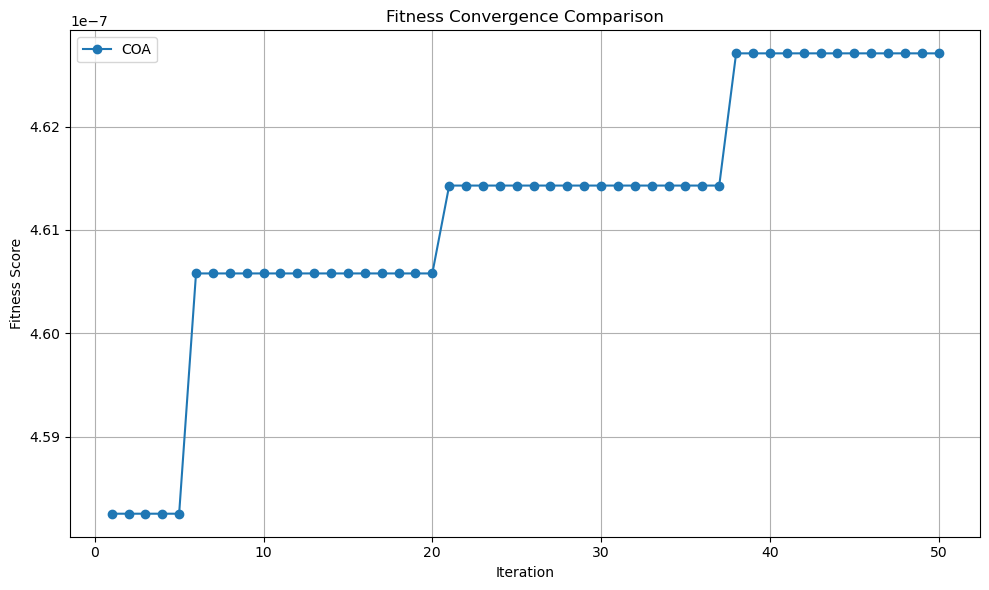

In [45]:
plt.figure(figsize=(10,6))

for r in results:
    if r['history']['fitness']:
        plt.plot(
            range(1, len(r['history']['fitness'])+1),
            r['history']['fitness'],
            label=r['name'],
            marker='o'
        )

plt.xlabel("Iteration")
plt.ylabel("Fitness Score")
plt.title("Fitness Convergence Comparison")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Save summary and representative schedule CSVs

In [46]:
def save_all_results_to_single_txt(results, filename):
    with open(filename, 'w') as f:                        # buka sekali untuk write
        f.write("=== SUMMARY REPORT - OPTIMIZATION RESULTS ===\n")
        f.write(f"Total Algorithms Tested: {len(results)}\n")
        f.write("=" * 45 + "\n\n")

        for i, result in enumerate(results):              # ← for di DALAM with
            f.write(f"--- RESULT #{i+1}: {result['name']} ---\n")
            f.write(f"Best Fitness : {result['eval']['fitness']:.6f}\n")
            f.write(f"Runtime      : {result['runtime']:.2f} sec\n")
            f.write(f"Status       : {'FEASIBLE' if result['eval']['is_feasible'] else 'NOT FEASIBLE'}\n")
            f.write(f"Heavy Penalty: {result['eval']['heavy_total']}\n")
            f.write(f"Light Penalty: {result['eval']['light_total']}\n\n")

            f.write("=== HEAVY DETAIL ===\n")
            if result['eval']['heavy_detail']:
                for k, v in result['eval']['heavy_detail'].items():
                    f.write(f"  - {k}: {v}\n")
            else:
                f.write("  No heavy penalties.\n")

            f.write("\n=== LIGHT DETAIL ===\n")
            if result['eval']['light_detail']:
                for k, v in result['eval']['light_detail'].items():
                    f.write(f"  - {k}: {v}\n")
            else:
                f.write("  No light penalties.\n")

            f.write("\n" + "=" * 45 + "\n\n")

filename = "all_reports_Gabungan.txt"
save_all_results_to_single_txt(results, filename)
print(f"Laporan lengkap dengan Fitness Score berhasil disimpan ke {filename}")

Laporan lengkap dengan Fitness Score berhasil disimpan ke all_reports_Gabungan.txt


In [47]:
rows = []
 
for r in results:
    sched = r['schedule']
    for k, sessions in sched.items():
        mk = courses[k]
        for sess in sessions:
            day, hour, minute = available_slots[sess['slot']]
            start_min = hour * 60 + minute
            end_min   = start_min + SKS_DURATION
 
            room_meta = room_info.get(sess['room'], {})
 
            rows.append({
                'Algorithm'   : r['name'],
                'Hari'        : day,
                'Jam'         : hour,
                'Menit'       : minute,
                'Durasi_Menit': SKS_DURATION,
                'Jam_Mulai'   : f"{hour:02d}:{minute:02d}",
                'Jam_Selesai' : f"{end_min // 60:02d}:{end_min % 60:02d}",
                'Prodi'       : mk['prodi'],
                'Kode_MK'     : mk['kode'],
                'Kelas'       : mk['section'],                      # ← TAMBAH
                'Nama_MK'     : mk['nama'],
                'Jenis'       : sess['type'],
                'Ruang'       : sess['room'],
                'Gedung'      : room_meta.get('Gedung', ''),
                'Lantai'      : room_meta.get('Lantai', ''),
                'Tipe_Ruang'  : 'Lab' if sess['room'] in lab_room_codes else 'Kelas',
                'Dosen'       : mk['dosen'],
                'Dosen_Asli'  : mk['dosen_asli'],                    # ← TAMBAH
                'Is_Substitusi': mk['is_substitusi'],                # ← TAMBAH
                'SKS'         : mk['sks'],
                'Kewajiban'   : mk['kewajiban'],
                'Prioritas'   : mk['prioritas'],
                'Fitness'     : r['eval']['fitness'],
                'Heavy_Total' : r['eval']['heavy_total'],
                'Light_Total' : r['eval']['light_total'],
                'Feasible'    : r['eval']['is_feasible']
            })
 
df_schedule_all = pd.DataFrame(rows)
df_schedule_all.to_csv("Gabungan_Schedules.csv", index=False)
print("Kolom CSV:", df_schedule_all.columns.tolist())

Kolom CSV: ['Algorithm', 'Hari', 'Jam', 'Menit', 'Durasi_Menit', 'Jam_Mulai', 'Jam_Selesai', 'Prodi', 'Kode_MK', 'Kelas', 'Nama_MK', 'Jenis', 'Ruang', 'Gedung', 'Lantai', 'Tipe_Ruang', 'Dosen', 'Dosen_Asli', 'Is_Substitusi', 'SKS', 'Kewajiban', 'Prioritas', 'Fitness', 'Heavy_Total', 'Light_Total', 'Feasible']


In [48]:
# rows = []
 
# for r in results:
#     sched = r['schedule']
#     for k, sessions in sched.items():
#         for sess in sessions:
#             day, hour, minute = available_slots[sess['slot']]
#             start_min = hour * 60 + minute
#             end_min   = start_min + SKS_DURATION
#             rows.append({
#                 'Algorithm'  : r['name'],
#                 'Hari'       : day,
#                 'Jam'        : hour,
#                 'Jam_Mulai'  : f"{hour:02d}:{minute:02d}",
#                 'Jam_Selesai': f"{end_min // 60:02d}:{end_min % 60:02d}",
#                 'Prodi'      : courses[k]['prodi'],
#                 'Kode_MK'    : courses[k]['kode'],
#                 'Nama_MK'    : courses[k]['nama'],
#                 'Jenis'      : sess['type'],
#                 'Ruang'      : sess['room'],
#                 'Dosen'      : courses[k]['dosen'],
#                 'SKS'        : courses[k]['sks'],
#                 'Kewajiban'  : courses[k]['kewajiban'],
#                 'Prioritas'  : courses[k]['prioritas'], 
#                 'Fitness'    : r['eval']['fitness'],
#                 'Heavy_Total': r['eval']['heavy_total'],
#                 'Light_Total': r['eval']['light_total'],
#                 'Feasible'   : r['eval']['is_feasible']
#             })
 
# df_schedule_all = pd.DataFrame(rows)
# df_schedule_all.to_csv("Gabungan_Schedules.csv", index=False)

# UJI NORMALITAS (SHAPIRO–WILK)

In [49]:
from scipy.stats import shapiro

fitness_values = [r['eval']['light_total'] for r in results]  # ambil semua, bukan filter

if len(fitness_values) < 3:
    print("Data tidak cukup untuk uji normalitas (minimal 3 sampel)")
else:
    stat, p = shapiro(fitness_values)
    print(f"Shapiro-Wilk: stat={stat:.4f}, p={p:.4f}")
    print("Normal" if p > 0.05 else "Tidak normal")


Data tidak cukup untuk uji normalitas (minimal 3 sampel)
